In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

In [13]:
# --- 1. 데이터 로드 및 전처리 ---

# 데이터셋이 압축 해제된 경로
DATASET_PATH = '/content/drive/MyDrive/UCI HAR Dataset/'



In [16]:
# 원시 신호 데이터를 로드하는 함수
def load_signal_data(split): # split = 'train' 또는 'test'
    # 9개 축의 파일 리스트
    signal_files = [
        f'body_acc_x_{split}.txt', f'body_acc_y_{split}.txt', f'body_acc_z_{split}.txt',
        f'body_gyro_x_{split}.txt', f'body_gyro_y_{split}.txt', f'body_gyro_z_{split}.txt',
        f'total_acc_x_{split}.txt', f'total_acc_y_{split}.txt', f'total_acc_z_{split}.txt'
    ]

    # 데이터를 담을 리스트
    signal_data = []

    # 9개 파일을 순서대로 읽어서 리스트에 추가
    for file_name in signal_files:
        file_path = f'{DATASET_PATH}{split}/Inertial Signals/{file_name}'
        # 공백으로 구분된 텍스트 파일을 로드
        df = pd.read_csv(file_path, delim_whitespace=True, header=None)
        # NumPy 배열로 변환하여 리스트에 추가
        signal_data.append(df.values)

    # (9, 샘플 수, 128) 형태의 리스트를 (샘플 수, 128, 9) 형태로 변환
    # np.stack을 사용해 3번째 축(특징 축)으로 쌓음
    X_data = np.stack(signal_data, axis=-1)

    return X_data

# 라벨 데이터를 로드하는 함수
def load_label_data(split): # split = 'train' 또는 'test'
    file_path = f'{DATASET_PATH}{split}/y_{split}.txt'
    df = pd.read_csv(file_path, header=None)

    # 라벨이 1부터 6까지이므로 0부터 5까지로 조정 (원-핫 인코딩을 위해)
    y_data = df.values - 1

    # 원-핫 인코딩 수행
    return to_categorical(y_data, num_classes=6)

# 데이터 로드 실행
print("데이터 로딩 시작...")
X_train = load_signal_data('train')
X_test = load_signal_data('test')
y_train = load_label_data('train')
y_test = load_label_data('test')

# 데이터 형태 확인
# (샘플 수, 타임스텝, 특징 수)
# (7352, 128, 9) -> 7352개의 훈련 샘플, 각 샘플은 128 타임스텝, 각 타임스텝은 9개 센서값
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape) # (7352, 6) -> 6개 클래스 원-핫 인코딩
print("X_test shape:", X_test.shape)   # (2947, 128, 9)
print("y_test shape:", y_test.shape)   # (2947, 6)

데이터 로딩 시작...


/tmp/ipython-input-1119463623.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1119463623.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1119463623.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1119463623.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-1

X_train shape: (7352, 128, 9)
y_train shape: (7352, 6)
X_test shape: (2947, 128, 9)
y_test shape: (2947, 6)


In [26]:
# --- 2. GRU 모델 구축 ---

print("\nGRU 모델 구축 시작...")
n_timesteps = X_train.shape[1] # 128
n_features = X_train.shape[2]  # 9
n_classes = y_train.shape[1]   # 6

model = Sequential()
# 입력 형태: (128, 9)
# GRU 레이어 (유닛 100개). return_sequences=True는 다음 RNN 레이어가 있을 때 사용
model.add(GRU(64, input_shape=(n_timesteps, n_features)))
# 과적합 방지를 위한 Dropout
model.add(Dropout(0.5))
# 다중 클래스 분류를 위한 Dense 레이어
model.add(Dense(100, activation='relu'))
# 출력 레이어 (6개 클래스, 소프트맥스 활성화)
model.add(Dense(n_classes, activation='softmax'))

# 모델 구조 요약
model.summary()


GRU 모델 구축 시작...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,506 (84.01 KB)

 Trainable params: 21,506 (84.01 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# --- 3. 모델 컴파일 및 학습 ---

print("\n모델 컴파일 및 학습 시작...")

# 모델 컴파일
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy', # 다중 클래스 분류 손실 함수
              optimizer='adam',                 # 옵티마이저
              metrics=['accuracy'])             # 평가지표



from tensorflow.keras.callbacks import EarlyStopping
# 검증 손실(val_loss)이 5번의 epoch 동안 개선되지 않으면 훈련을 중지
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ...

# model.fit()을 호출할 때 callbacks에 추가
history = model.fit(X_train, y_train,
                    epochs=30, # (30으로 두어도 조기 종료됨)
                    batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping]) # <--- 이 부분 추가



# 모델 학습
history = model.fit(X_train, y_train,
                    epochs=30,          # 훈련 횟수
                    batch_size=32,      # 배치 크기
                    validation_data=(X_test, y_test)) # 검증 데이터


모델 컴파일 및 학습 시작...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9617 - loss: 0.0908 - val_accuracy: 0.9267 - val_loss: 0.3519
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9660 - loss: 0.0879 - val_accuracy: 0.9196 - val_loss: 0.3361
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9597 - loss: 0.1170 - val_accuracy: 0.9237 - val_loss: 0.3240
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9652 - loss: 0.0899 - val_accuracy: 0.9226 - val_loss: 0.3097
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9706 - loss: 0.0735 - val_accuracy: 0.9372 - val_loss: 0.3391
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9657 - loss: 0.0912 - val_accuracy: 0.9379 - val_loss: 0.3470
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9672 - loss: 0.0847 - val_accuracy: 0.9158 - val_loss: 0.3945
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9675 - loss

In [30]:
# --- 4. 모델 평가 ---

print("\n모델 평가 시작...")
loss, accuracy = model.evaluate(X_test, y_test)
print(f'테스트 데이터 손실(Loss): {loss:.4f}')
print(f'테스트 데이터 정확도(Accuracy): {accuracy * 100:.2f} %')


모델 평가 시작...
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9443 - loss: 0.3136
테스트 데이터 손실(Loss): 0.2951
테스트 데이터 정확도(Accuracy): 94.88 %



--- 학습 커브 그리기 ---


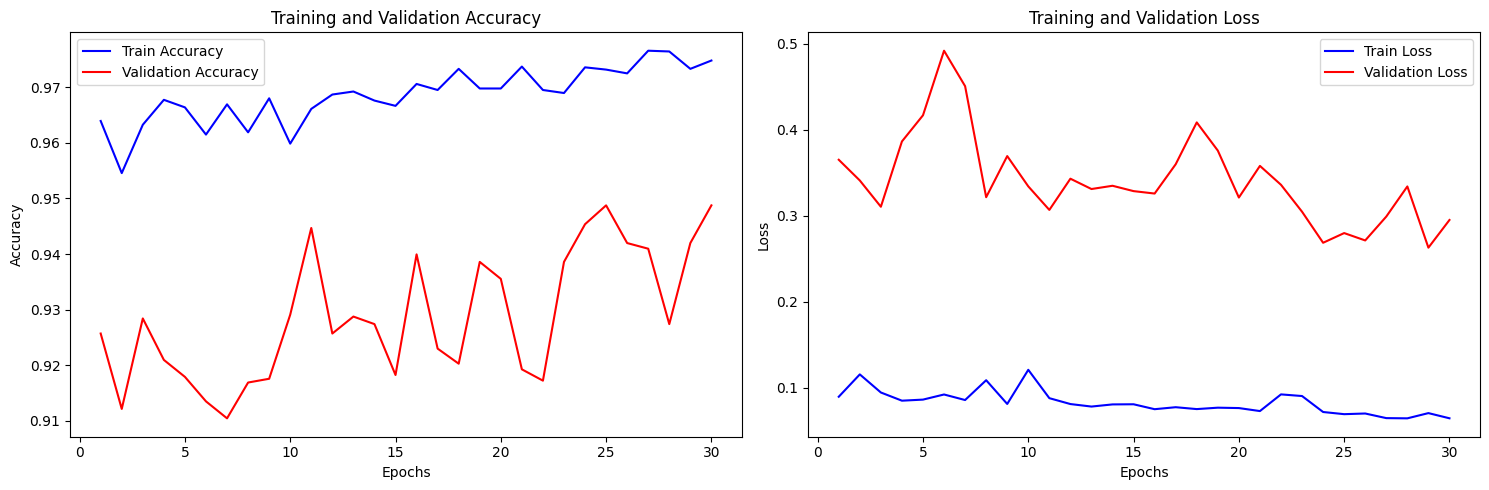

In [31]:
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. 학습 커브 (정확도 및 손실)
# ----------------------------------------
print("\n--- 학습 커브 그리기 ---")

# history 객체에서 훈련 및 검증 정확도/손실 추출
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# 에포크 수
epochs = range(1, len(train_acc) + 1)

# 1x2 크기의 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 📈 첫 번째 플롯: 정확도 (Accuracy)
ax1.plot(epochs, train_acc, 'b-', label='Train Accuracy')       # 훈련 정확도
ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')  # 검증 정확도
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# 📉 두 번째 플롯: 손실 (Loss)
ax2.plot(epochs, train_loss, 'b-', label='Train Loss')       # 훈련 손실
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')  # 검증 손실
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# 플롯 표시
plt.tight_layout() # 플롯 간 간격 조절
plt.show()


--- 혼동 행렬 그리기 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


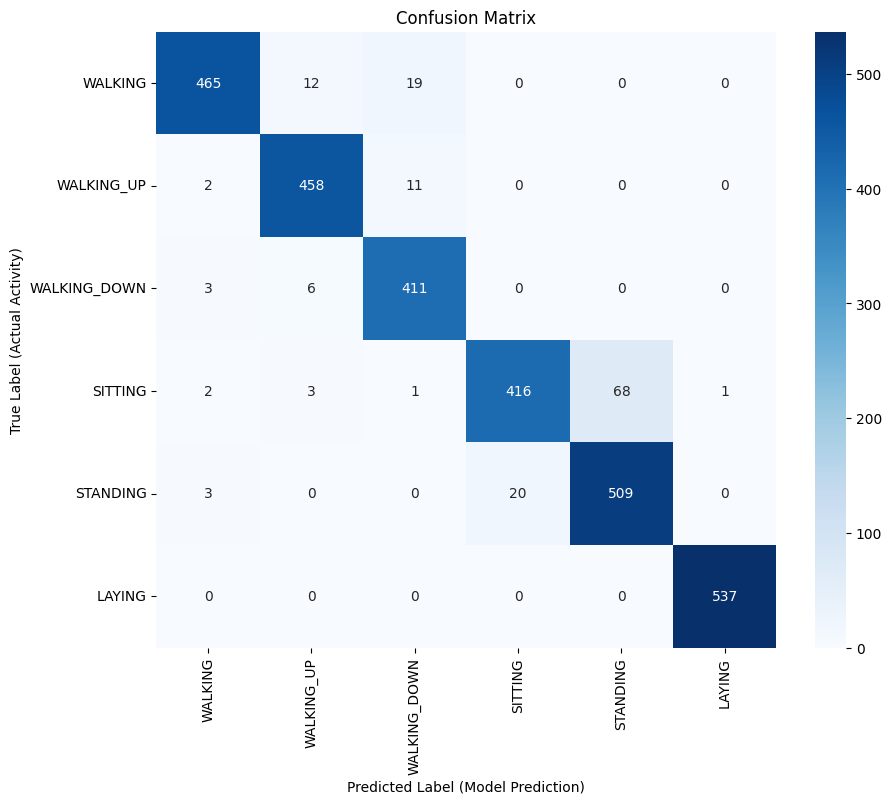

In [32]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ----------------------------------------
# 2. 혼동 행렬 (Confusion Matrix)
# ----------------------------------------
print("\n--- 혼동 행렬 그리기 ---")

# 테스트 데이터(X_test)로 예측 수행
y_pred_probs = model.predict(X_test)

# 확률(probs)을 가장 높은 확률을 가진 클래스 인덱스로 변환
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 원-핫 인코딩된 y_test를 다시 클래스 인덱스로 변환
y_true = np.argmax(y_test, axis=1)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred_classes)

# 클래스(동작) 이름 정의 (UCI HAR Dataset 기준: 1~6)
# 0: WALKING, 1: WALKING_UPSTAIRS, 2: WALKING_DOWNSTAIRS, 3: SITTING, 4: STANDING, 5: LAYING
class_names = [
    'WALKING', 'WALKING_UP', 'WALKING_DOWN',
    'SITTING', 'STANDING', 'LAYING'
]

# Seaborn을 사용해 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label (Actual Activity)')
plt.xlabel('Predicted Label (Model Prediction)')
plt.show()